# Gradient Free Optimization


Methods of optimization that does not use the gradient as a crucial component

# Genetic Algorithm

In [48]:
import numpy as np
import matplotlib.pyplot as plt

In [94]:
true_params = np.array([np.sqrt(2)*100,np.pi*100])

fitness_func = lambda x: ((true_params - x)**2).sum(axis=1) # L2 norm

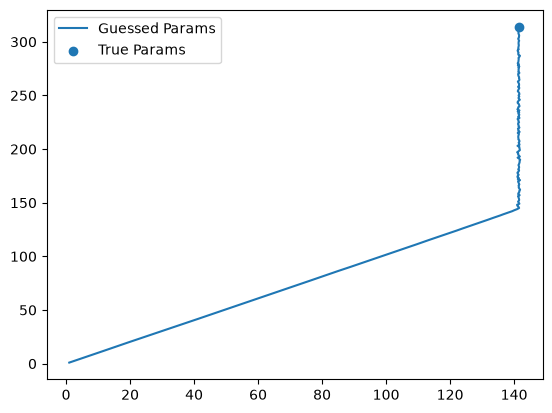

In [95]:
initial_guess = np.array([0,0])
guess_history = []
generation_history = []

num_steps = 1000
guess = initial_guess
for i in range(num_steps):
    random_steps = np.random.uniform(-1,1, size=(10000,2))
    random_generation = guess + random_steps
    generation_fitness = fitness_func(random_generation)
    best_step_index = np.argmin(generation_fitness)
    guess = random_generation[best_step_index,:]

    # update history
    guess_history.append(guess)
    generation_history.append(random_generation)

guess_matrix = np.asarray(guess_history)
plt.plot(guess_matrix[:,0], guess_matrix[:,1], label="Guessed Params")
plt.scatter(true_params[0], true_params[1], label="True Params")
plt.legend()

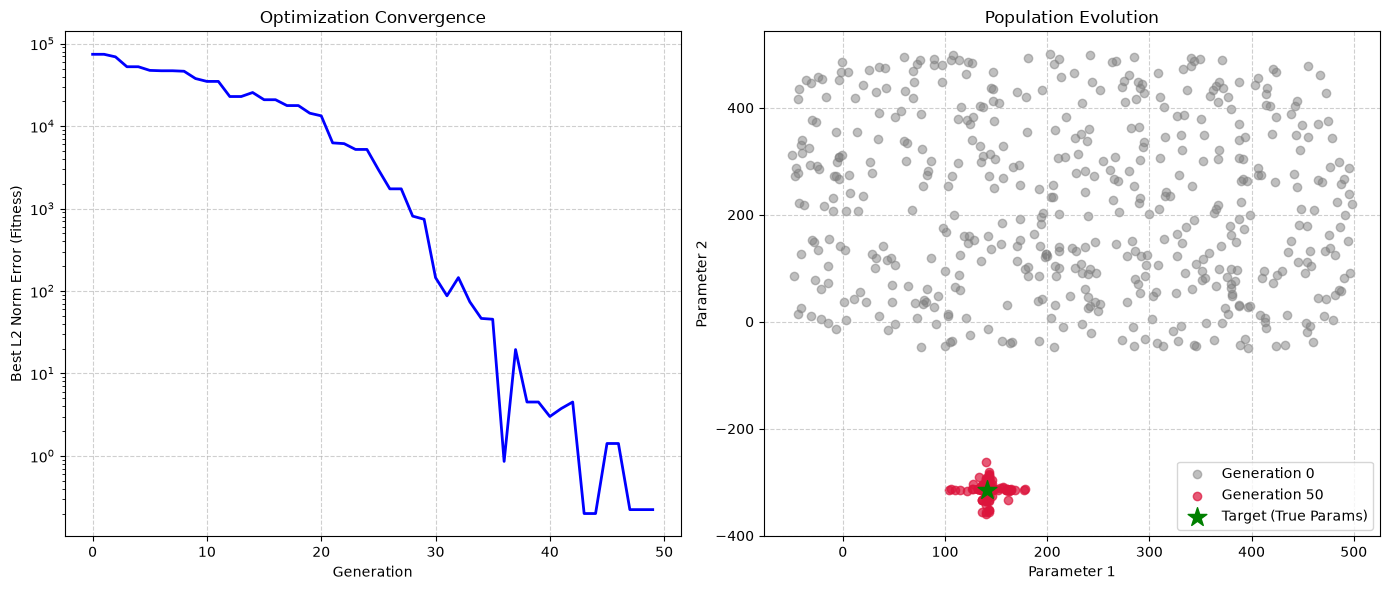

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup problem
true_params = np.array([np.sqrt(2) * 100, -np.pi * 100])
fitness_func = lambda x: ((true_params - x) ** 2).sum(axis=1)

# GA Hyperparameters
pop_size = 500
num_generations = 50
mutation_rate = 0.1

# Initialize population randomly
population = np.random.uniform(-50, 500, size=(pop_size, 2))

# Track history for plotting
best_fitness_history = []
population_history = []

# 2. Run Genetic Algorithm
for generation in range(num_generations):
    # Evaluate fitness
    fitness = fitness_func(population)
    
    # Track best score of this generation
    best_fitness_history.append(np.min(fitness))
    population_history.append(population.copy())
    
    # Selection (Tournament selection)
    tournament_indices = np.random.randint(0, pop_size, size=(pop_size, 2))
    tournament_fitness = fitness[tournament_indices]
    winner_col = np.argmin(tournament_fitness, axis=1)
    parents = population[tournament_indices[np.arange(pop_size), winner_col]]
    
    # Crossover (Single-point/mask crossover)
    mask = np.random.rand(pop_size, 1) < 0.5
    shuffled_indices = np.random.permutation(pop_size)
    parent1 = parents
    parent2 = parents[shuffled_indices]
    offspring = np.where(mask, parent1, parent2)
    
    # Mutation
    mutation_mask = np.random.rand(pop_size, 2) < mutation_rate
    mutation_values = np.random.normal(0, 20, size=(pop_size, 2))
    offspring[mutation_mask] += mutation_values[mutation_mask]
    
    population = offspring

# 3. Plotting the Progression
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot A: Convergence Curve (Best Fitness per Generation)
ax1.plot(best_fitness_history, color='b', lw=2)
ax1.set_title("Optimization Convergence")
ax1.set_xlabel("Generation")
ax1.set_ylabel("Best L2 Norm Error (Fitness)")
ax1.set_yscale('log')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot B: Population Spread (Initial vs Final Population)
initial_pop = population_history[0]
final_pop = population_history[-1]

ax2.scatter(initial_pop[:, 0], initial_pop[:, 1], color='gray', alpha=0.5, label='Generation 0')
ax2.scatter(final_pop[:, 0], final_pop[:, 1], color='crimson', alpha=0.7, label=f'Generation {num_generations}')
ax2.scatter(true_params[0], true_params[1], color='green', marker='*', s=200, label='Target (True Params)')

ax2.set_title("Population Evolution")
ax2.set_xlabel("Parameter 1")
ax2.set_ylabel("Parameter 2")
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()